   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 5.2 MB/s eta 0:00:00
HMM training completed.
Adjusted Rand Index: 1.0
Log Likelihood: -1687.2719525357522

Learned Transition Matrix:
[[0.87121212 0.12878788]
 [0.10778443 0.89221557]]

Predicted Hidden States (first 20):
[1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 0 1 1]


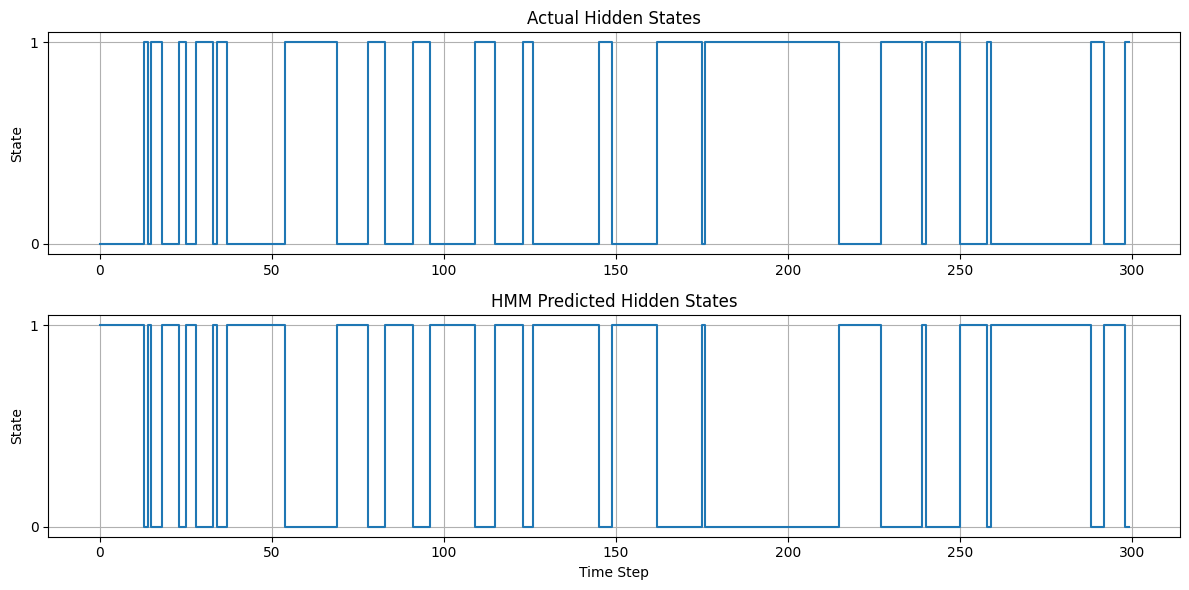

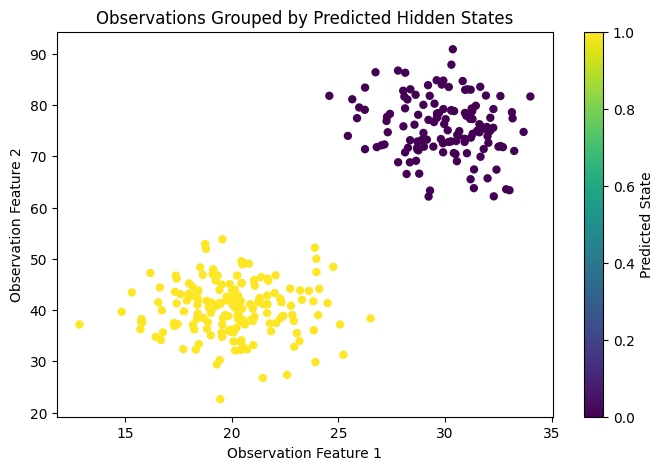

In [1]:
# Step 1: Install required library
!pip install hmmlearn -q

# Step 2: Import libraries
import numpy as np
import matplotlib.pyplot as plt

from hmmlearn.hmm import GaussianHMM
from sklearn.metrics import adjusted_rand_score

# Set random seed
np.random.seed(42)

# Step 3: Generate synthetic hidden states
n_samples = 300

# Transition probabilities between two hidden states
transition_matrix = np.array([
    [0.90, 0.10],
    [0.15, 0.85]
])

# Observation means for each hidden state
means = np.array([
    [20, 40],
    [30, 75]
])

# Observation covariance matrices
covariances = np.array([
    [[4, 0], [0, 25]],
    [[4, 0], [0, 25]]
])

# Generate hidden states
hidden_states = np.zeros(n_samples, dtype=int)

hidden_states[0] = np.random.choice([0, 1])

for i in range(1, n_samples):
    hidden_states[i] = np.random.choice(
        [0, 1],
        p=transition_matrix[hidden_states[i - 1]]
    )

# Step 4: Generate observations from hidden states
observations = np.zeros((n_samples, 2))

for i in range(n_samples):
    state = hidden_states[i]
    observations[i] = np.random.multivariate_normal(
        means[state],
        covariances[state]
    )

# Step 5: Create and train the Gaussian HMM
model = GaussianHMM(
    n_components=2,
    covariance_type="full",
    n_iter=100,
    random_state=42
)

model.fit(observations)

print("HMM training completed.")

# Step 6: Predict hidden states using Viterbi algorithm
predicted_states = model.predict(observations)

# Step 7: Evaluate the predicted states
ari = adjusted_rand_score(
    hidden_states,
    predicted_states
)

log_likelihood = model.score(observations)

print("Adjusted Rand Index:", ari)
print("Log Likelihood:", log_likelihood)

print("\nLearned Transition Matrix:")
print(model.transmat_)

print("\nPredicted Hidden States (first 20):")
print(predicted_states[:20])

# Step 8: Visualize actual and predicted hidden states
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(hidden_states, drawstyle="steps-post")
plt.title("Actual Hidden States")
plt.ylabel("State")
plt.yticks([0, 1])
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(predicted_states, drawstyle="steps-post")
plt.title("HMM Predicted Hidden States")
plt.xlabel("Time Step")
plt.ylabel("State")
plt.yticks([0, 1])
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 9: Visualize the observations
plt.figure(figsize=(8, 5))

plt.scatter(
    observations[:, 0],
    observations[:, 1],
    c=predicted_states,
    cmap="viridis",
    s=25
)

plt.xlabel("Observation Feature 1")
plt.ylabel("Observation Feature 2")
plt.title("Observations Grouped by Predicted Hidden States")
plt.colorbar(label="Predicted State")
plt.show()